# 01 — EDA et préparation
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 1** du sujet : analyse de la cible, des valeurs manquantes,
des distributions, des catégories, des valeurs atypiques et des relations temporelles.

Le code réutilisable (chargement des données, configuration) est factorisé dans le package
`src/`, importé ci-dessous.

## 0. Configuration et chargement des données

In [1]:
import sys, os
# Résolution robuste du chemin racine du projet, que ce notebook soit exécuté
# seul depuis notebooks/ ou fusionné à la racine dans notebook.ipynb
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.config import RANDOM_STATE
from src.data import load_train_test

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

print("Setup OK — graine aléatoire fixée à", RANDOM_STATE)

Setup OK — graine aléatoire fixée à 42


In [2]:
train, test, data_dict = load_train_test()

print("Train :", train.shape)
print("Test  :", test.shape)
train.head()

Train : (8000, 34)
Test  : (2000, 33)


,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,canal_reservation,moyen_transport,delai_reservation_jours,nuits,adultes,enfants,chambres,formule_repas,tarif_remboursable,type_acompte,prix_moyen_nuit_eur,remise_pct,montant_total_eur,client_type,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,plateforme_en_ligne,avion_direct,71,4,2,0.0,1,aucune,non,total,165.72,3,642.99,nouveau,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,plateforme_en_ligne,train,6,3,2,1.0,1,petit_dejeuner,oui,partiel,187.00,0,561.00,fidele,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,agence,avion_direct,84,3,2,0.0,1,aucune,oui,aucun,180.61,1,536.41,nouveau,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,plateforme_en_ligne,voiture,8,3,2,1.0,1,petit_dejeuner,oui,aucun,202.10,7,563.86,nouveau,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,site_hotel,ferry,10,4,2,0.0,1,petit_dejeuner,non,total,138.89,4,533.34,nouveau,0,0,2.0,1,0,0,0,0,NaN,0


In [3]:
data_dict

,variable,type,description,fichier_test
0,reservation_id,identifiant,Identifiant unique de la réservation,oui
1,date_reservation,date,Date de création de la réservation,oui
2,date_arrivee,date,Date d’arrivée prévue,oui
3,region_hotel,catégorielle,Région administrative italienne de l’hôtel,oui
4,ville,catégorielle,Ville principale associée à l’établissement,oui
5,type_destination,catégorielle,Profil touristique dominant de la destination,oui
6,hotel_id,catégorielle,Identifiant synthétique de l’hôtel,oui
7,categorie_hotel,entier,"Catégorie de l’hôtel, en étoiles",oui
8,segment_client,catégorielle,Motif ou composition principale du séjour,oui
9,marche_origine,catégorielle,"Grande zone de marché, non assimilable à une n...",oui


### 1.1 Vue d'ensemble et typage

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   reservation_id             8000 non-null   str           
 1   date_reservation           8000 non-null   datetime64[us]
 2   date_arrivee               8000 non-null   datetime64[us]
 3   region_hotel               8000 non-null   str           
 4   ville                      8000 non-null   str           
 5   type_destination           8000 non-null   str           
 6   hotel_id                   8000 non-null   str           
 7   categorie_hotel            8000 non-null   int64         
 8   segment_client             8000 non-null   str           
 9   marche_origine             7809 non-null   str           
 10  canal_reservation          8000 non-null   str           
 11  moyen_transport            8000 non-null   str           
 12  delai_reservation

### 1.2 Distribution de la cible

La cible est déséquilibrée : environ un quart des réservations sont annulées. C'est ce déséquilibre,
combiné à l'asymétrie du coût des erreurs (voir README), qui justifie l'usage du **F1-score** plutôt
que l'accuracy comme métrique d'évaluation (une accuracy élevée peut être obtenue en prédisant
toujours « pas d'annulation »).

reservation_annulee
0    0.741625
1    0.258375
Name: proportion, dtype: float64


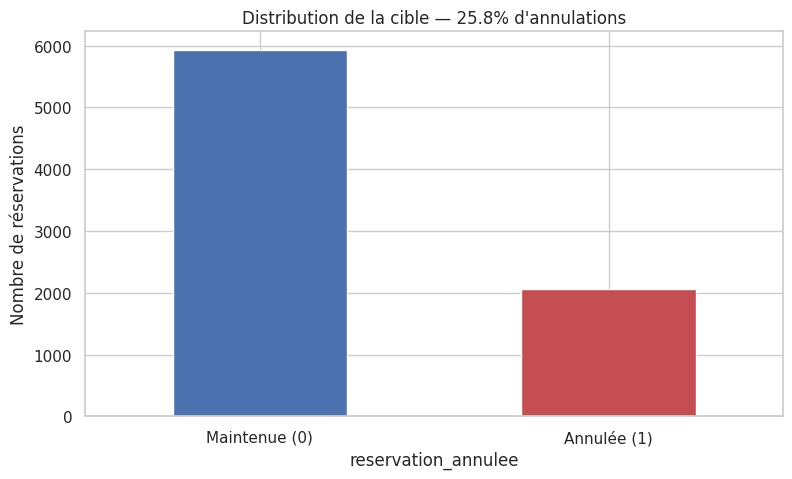

In [5]:
target_rate = train["reservation_annulee"].value_counts(normalize=True)
print(target_rate)

fig, ax = plt.subplots()
train["reservation_annulee"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Maintenue (0)", "Annulée (1)"], rotation=0)
ax.set_title(f"Distribution de la cible — {target_rate[1]*100:.1f}% d'annulations")
ax.set_ylabel("Nombre de réservations")
plt.show()

### 1.3 Valeurs manquantes

On inspecte les valeurs manquantes dans le train et le test. Un point important : `agent_id` n'est pas
une variable "manquante" au sens statistique — elle est **structurellement vide** pour les canaux de
réservation directs (site hôtel, téléphone, entreprise) et toujours renseignée pour les canaux
intermédiés (agence, plateforme en ligne). Ce n'est donc pas un problème à imputer, mais une information
déjà capturée par `canal_reservation`.

In [6]:
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_pct = (missing_train / len(train) * 100).round(2)
pd.DataFrame({"n_manquant": missing_train, "%_manquant": missing_pct})

,n_manquant,%_manquant
agent_id,3354,41.92
enfants,355,4.44
prix_moyen_nuit_eur,193,2.41
marche_origine,191,2.39
demandes_speciales,157,1.96


In [7]:
# Vérification : agent_id manquant <=> canal de réservation direct
pd.crosstab(train["canal_reservation"], train["agent_id"].isna(), rownames=["canal_reservation"], colnames=["agent_id manquant"])

agent_id manquant,False,True
canal_reservation,,
agence,1325,0
entreprise,0,622
plateforme_en_ligne,3321,0
site_hotel,0,2013
telephone,0,719


In [8]:
# Les autres valeurs manquantes (marche_origine, enfants, prix_moyen_nuit_eur, demandes_speciales)
# sont-elles liées à la cible ? Si le taux d'annulation est similaire manquant/présent, on peut
# considérer une imputation simple sans risque de biais fort.
for c in ["marche_origine", "enfants", "prix_moyen_nuit_eur", "demandes_speciales"]:
    m = train[c].isna()
    print(f"{c:25s} | taux annulation (manquant)={train.loc[m,'reservation_annulee'].mean():.3f} "
          f"| (présent)={train.loc[~m,'reservation_annulee'].mean():.3f} | n_manquant={m.sum()}")

marche_origine            | taux annulation (manquant)=0.209 | (présent)=0.260 | n_manquant=191
enfants                   | taux annulation (manquant)=0.282 | (présent)=0.257 | n_manquant=355
prix_moyen_nuit_eur       | taux annulation (manquant)=0.181 | (présent)=0.260 | n_manquant=193
demandes_speciales        | taux annulation (manquant)=0.280 | (présent)=0.258 | n_manquant=157


**Décision de traitement des valeurs manquantes** (appliquée uniquement avec des statistiques
apprises sur le train, dans le pipeline scikit-learn de `src/preprocessing.py`, pour éviter toute
fuite) :

- `enfants`, `demandes_speciales` : imputation par la **médiane** (variables de comptage, distribution
  asymétrique) ;
- `prix_moyen_nuit_eur` : imputation par la **médiane** ;
- `marche_origine` : imputation par une catégorie explicite `"Inconnu"` plutôt que le mode, pour ne pas
  fabriquer un signal artificiel ;
- `agent_id` : conservé comme catégorie (`NaN` → `"direct"`), redondant avec `canal_reservation` mais
  utile si l'on veut capter un effet agent.

### 1.4 Cardinalité des variables catégorielles

In [9]:
cat_cols = ["region_hotel", "ville", "type_destination", "hotel_id", "categorie_hotel",
            "segment_client", "marche_origine", "canal_reservation", "moyen_transport",
            "formule_repas", "tarif_remboursable", "type_acompte", "client_type", "agent_id"]

card = pd.Series({c: train[c].nunique() for c in cat_cols}).sort_values(ascending=False)
card

hotel_id              84
agent_id              45
ville                 10
type_destination      10
region_hotel          10
marche_origine         6
moyen_transport        5
segment_client         5
canal_reservation      5
formule_repas          4
categorie_hotel        3
type_acompte           3
client_type            3
tarif_remboursable     2
dtype: int64

On remarque que `region_hotel`, `ville` et `type_destination` sont en **relation biunivoque** (1 région
= 1 ville = 1 type de destination) : ce sont trois vues de la même dimension géographique. On ne
conservera que `type_destination` (plus riche en information touristique) et `hotel_id` sera également
écarté (84 modalités, redondant, risque de sur-apprentissage) — décision appliquée dans
`src/config.DROP_COLS`, réutilisée dès le notebook 02.

In [10]:
(train.groupby("region_hotel")[["ville", "type_destination"]]
     .nunique()
     .rename(columns=lambda c: f"n_{c}_distincts"))

,n_ville_distincts,n_type_destination_distincts
region_hotel,,
Campania,1,1
Lazio,1,1
Liguria,1,1
Lombardia,1,1
Puglia,1,1
Sardegna,1,1
Sicilia,1,1
Toscana,1,1
Trentino-Alto_Adige,1,1


### 1.5 Taux d'annulation par variable catégorielle

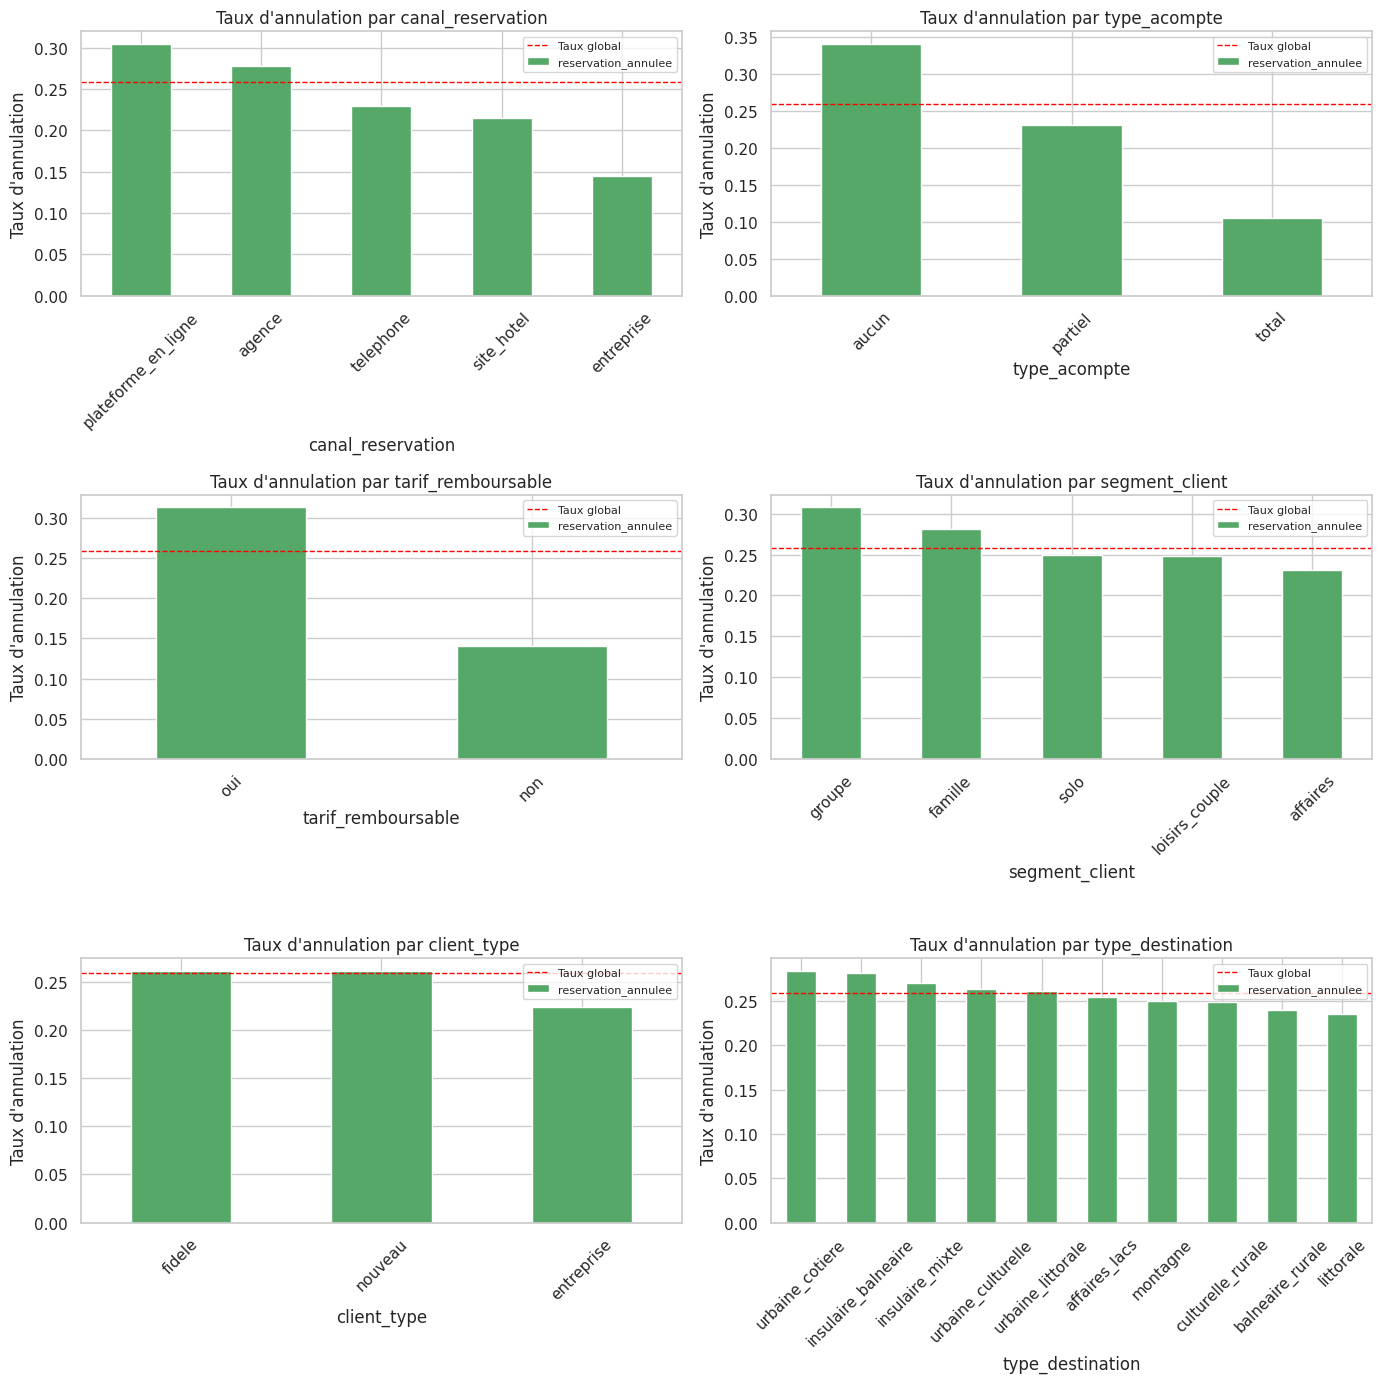

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
plot_cols = ["canal_reservation", "type_acompte", "tarif_remboursable",
             "segment_client", "client_type", "type_destination"]

for ax, c in zip(axes.ravel(), plot_cols):
    rate = train.groupby(c)["reservation_annulee"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#55A868")
    ax.axhline(train["reservation_annulee"].mean(), color="red", linestyle="--", linewidth=1, label="Taux global")
    ax.set_title(f"Taux d'annulation par {c}")
    ax.set_ylabel("Taux d'annulation")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Constats majeurs :**

- `type_acompte` et `tarif_remboursable` sont les variables catégorielles les plus discriminantes :
  une réservation avec acompte total est annulée dans ~10% des cas contre ~34% sans acompte ; un tarif
  non remboursable tombe à ~14% contre ~31% pour un tarif remboursable. C'est cohérent avec l'intuition
  métier : plus la barrière de sortie financière est élevée, moins le client annule.
- `canal_reservation` présente un écart marqué : les réservations « entreprise » annulent peu (~14.5%),
  celles via plateforme en ligne beaucoup plus (~30.4%).
- `region_hotel` / `type_destination` montrent des écarts **faibles** (23.5% à 28.4%). On évite donc de
  présenter une région comme intrinsèquement « à risque » — l'écart s'explique plus probablement par le
  mix de segments clients et de canaux propre à chaque destination touristique que par une caractéristique
  régionale en soi.

### 1.6 Variables numériques : distribution et relation à la cible

In [12]:
num_cols = ["delai_reservation_jours", "nuits", "adultes", "enfants", "chambres",
            "prix_moyen_nuit_eur", "remise_pct", "montant_total_eur",
            "reservations_passees", "annulations_passees", "demandes_speciales",
            "modifications_reservation", "jours_liste_attente"]

train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
delai_reservation_jours,8000.0,41.379625,49.232410,1.00,16.000,29.00,49.00,584.00
nuits,8000.0,4.203375,2.524492,1.00,2.000,4.00,6.00,30.00
adultes,8000.0,2.086125,0.914364,1.00,2.000,2.00,2.00,6.00
enfants,7645.0,0.529235,0.943367,0.00,0.000,0.00,1.00,3.00
chambres,8000.0,1.266875,0.664423,1.00,1.000,1.00,1.00,4.00
prix_moyen_nuit_eur,7807.0,201.473548,62.550478,75.25,158.945,191.58,233.21,848.42
remise_pct,8000.0,4.999625,3.649629,0.00,2.000,5.00,7.00,18.00
montant_total_eur,8000.0,1009.584740,879.585635,85.44,475.615,786.95,1252.42,13509.19
reservations_passees,8000.0,2.416875,3.785879,0.00,0.000,0.00,4.00,12.00
annulations_passees,8000.0,0.341250,0.602573,0.00,0.000,0.00,1.00,3.00


In [13]:
corr = (train[num_cols + ["reservation_annulee"]]
        .corr()["reservation_annulee"]
        .drop("reservation_annulee")
        .sort_values(key=abs, ascending=False))
corr

delai_reservation_jours      0.110531
modifications_reservation    0.059761
remise_pct                  -0.055104
demandes_speciales          -0.054611
chambres                     0.049157
adultes                      0.038409
montant_total_eur            0.037113
enfants                      0.035526
prix_moyen_nuit_eur          0.025695
reservations_passees        -0.018079
jours_liste_attente         -0.013521
annulations_passees         -0.011547
nuits                        0.008781
Name: reservation_annulee, dtype: float64

Les corrélations linéaires (Pearson) avec la cible sont globalement faibles — attendu pour des données
synthétiques et une cible binaire. `delai_reservation_jours` ressort comme la variable numérique la plus
liée à la cible, mais la relation est **non linéaire** (voir ci-dessous), ce qui suggère un potentiel de
feature engineering (binning ou transformation).

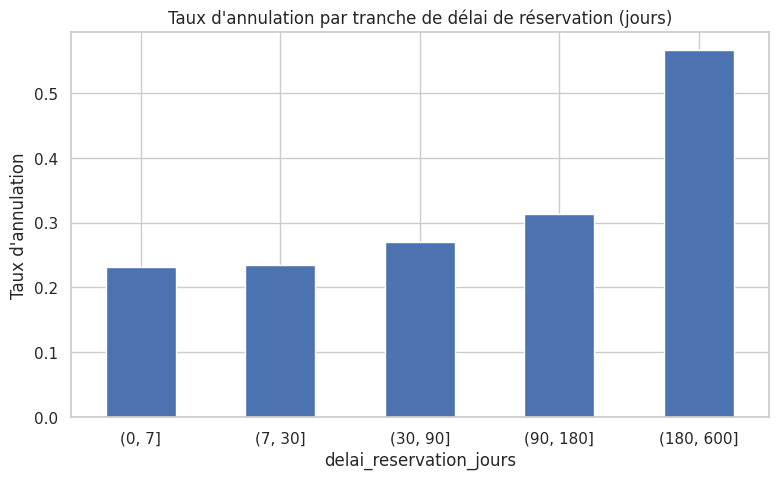

,mean,count
delai_reservation_jours,,
"(0, 7]",0.231527,406
"(7, 30]",0.234335,3862
"(30, 90]",0.270521,3131
"(90, 180]",0.313559,472
"(180, 600]",0.565891,129


In [14]:
fig, ax = plt.subplots()
bins = [0, 7, 30, 90, 180, 600]
delai_bin = pd.cut(train["delai_reservation_jours"], bins=bins)
rate = train.groupby(delai_bin, observed=True)["reservation_annulee"].agg(["mean", "count"])
rate["mean"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Taux d'annulation par tranche de délai de réservation (jours)")
ax.set_ylabel("Taux d'annulation")
ax.tick_params(axis="x", rotation=0)
plt.show()
rate

La relation est clairement non linéaire et croissante : le taux d'annulation double presque au-delà de
180 jours de délai entre réservation et arrivée (56.6% vs ~23-27% en dessous de 90 jours). Une réservation
prise très à l'avance laisse plus de temps aux imprévus (changement de plan, meilleure offre ailleurs,
etc.). **Note :** cette transformation par tranches (`delai_bin`) est calculée ici localement pour
l'exploration uniquement — elle n'est pas ajoutée à `train`, afin de ne pas polluer les features utilisées
dans les notebooks suivants.

### 1.7 Valeurs atypiques (outliers)

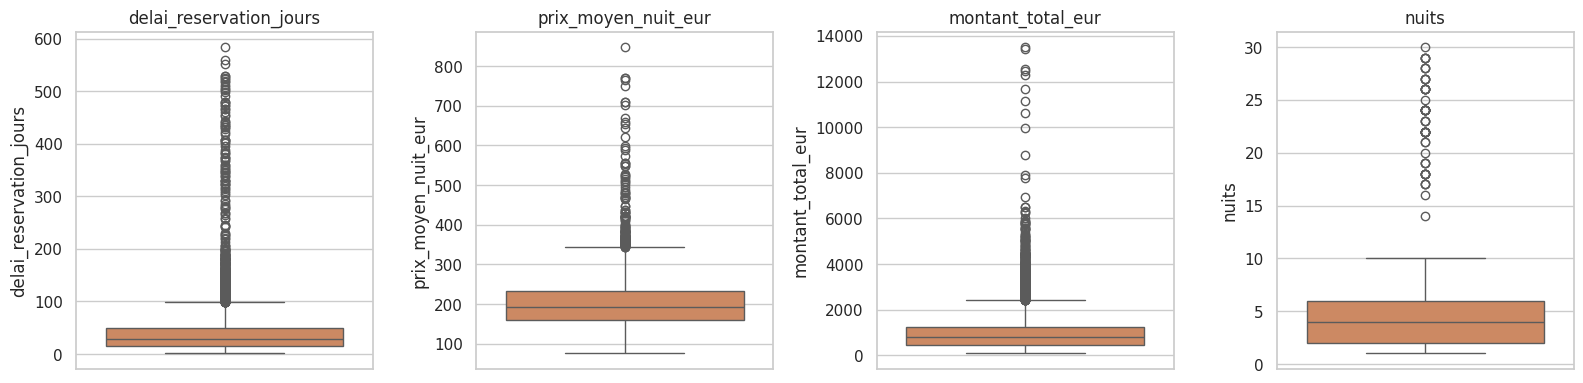

delai_reservation_jours   bornes IQR=(-33.5, 98.5)  outliers=492 (6.2%)
prix_moyen_nuit_eur       bornes IQR=(47.5, 344.6)  outliers=173 (2.2%)
montant_total_eur         bornes IQR=(-689.6, 2417.6)  outliers=459 (5.7%)
nuits                     bornes IQR=(-4.0, 12.0)  outliers=57 (0.7%)


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
outlier_cols = ["delai_reservation_jours", "prix_moyen_nuit_eur", "montant_total_eur", "nuits"]

for ax, c in zip(axes, outlier_cols):
    sns.boxplot(y=train[c], ax=ax, color="#DD8452")
    ax.set_title(c)

plt.tight_layout()
plt.show()

for c in outlier_cols:
    q1, q3 = train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((train[c] < lo) | (train[c] > hi)).sum()
    print(f"{c:25s} bornes IQR=({lo:.1f}, {hi:.1f})  outliers={n_out} ({n_out/len(train)*100:.1f}%)")

**Décision sur les outliers :** les valeurs extrêmes (délais de réservation très longs, prix ou montants
élevés) correspondent à des cas plausibles (réservations anticipées, hôtels 5 étoiles, longs séjours) et
non à des erreurs de saisie. On ne les supprime pas — les modèles arborescents (notebook 03) y sont
robustes par nature, et pour la régression logistique (notebook 02) on limitera leur influence via la
standardisation plutôt qu'une suppression, afin de ne perdre aucune observation.

### 1.8 Cohérence logique entre variables

On vérifie que `montant_total_eur` est bien dérivé de `prix_moyen_nuit_eur`, `nuits`, `chambres` et
`remise_pct`, ce qui confirme la qualité du jeu de données.

In [16]:
tmp = train.dropna(subset=["prix_moyen_nuit_eur"]).copy()
implied = tmp["prix_moyen_nuit_eur"] * tmp["nuits"] * tmp["chambres"] * (1 - tmp["remise_pct"] / 100)
diff = (tmp["montant_total_eur"] - implied).abs()
print("Écart médian entre montant_total_eur et le montant implicite reconstruit :", diff.median())
diff.describe()

Écart médian entre montant_total_eur et le montant implicite reconstruit : 0.0020999999999276042


count    7807.000000
mean        0.002255
std         0.001575
min         0.000000
25%         0.000800
50%         0.002100
75%         0.003600
max         0.005000
dtype: float64

### 1.9 Relations temporelles

Le sujet est explicite : **le jeu de test est postérieur au jeu d'entraînement**. On vérifie l'absence de
chevauchement et la stabilité (ou non) du taux d'annulation dans le temps, ce qui conditionne le protocole
de validation temporelle implémenté dans `src/data.temporal_split` (utilisé dès le notebook 02).

In [17]:
print("Train — date_reservation :", train["date_reservation"].min().date(), "→", train["date_reservation"].max().date())
print("Test  — date_reservation :", test["date_reservation"].min().date(), "→", test["date_reservation"].max().date())
print()
print("Train — date_arrivee :", train["date_arrivee"].min().date(), "→", train["date_arrivee"].max().date())
print("Test  — date_arrivee :", test["date_arrivee"].min().date(), "→", test["date_arrivee"].max().date())

Train — date_reservation : 2023-01-01 → 2025-05-24
Test  — date_reservation : 2025-05-24 → 2025-12-31

Train — date_arrivee : 2023-01-04 → 2026-06-02
Test  — date_arrivee : 2025-05-29 → 2027-03-11


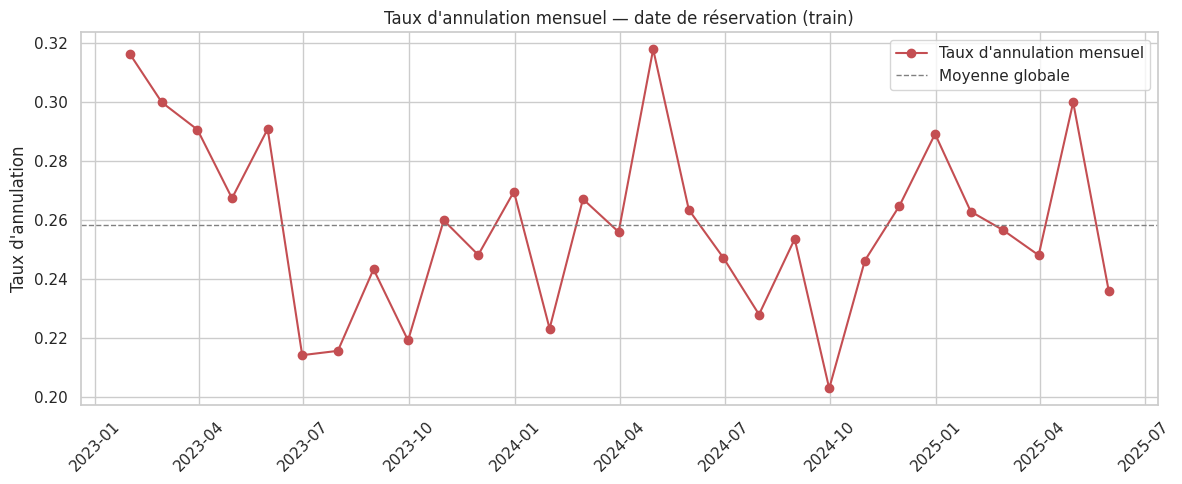

In [18]:
monthly = (train.set_index("date_reservation")["reservation_annulee"]
           .resample("ME").agg(["mean", "count"]))

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly.index, monthly["mean"], marker="o", color="#C44E52", label="Taux d'annulation mensuel")
ax1.axhline(train["reservation_annulee"].mean(), color="gray", linestyle="--", linewidth=1, label="Moyenne globale")
ax1.set_ylabel("Taux d'annulation")
ax1.set_title("Taux d'annulation mensuel — date de réservation (train)")
ax1.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Constat :** le taux d'annulation mensuel oscille entre ~20% et ~32% sans dérive tendancielle nette sur
la période 2023–2025 : les fluctuations semblent relever du bruit d'échantillonnage plutôt que d'un
changement structurel. C'est plutôt rassurant pour la généralisation temporelle, mais cela **ne dispense
pas** d'une validation respectant l'ordre chronologique : le test contient des réservations dont la
`date_reservation` démarre exactement là où s'arrête le train (24/05/2025), et une validation croisée
aléatoire mélangerait passé et futur, donnant une estimation optimiste et non représentative des
conditions réelles de déploiement.

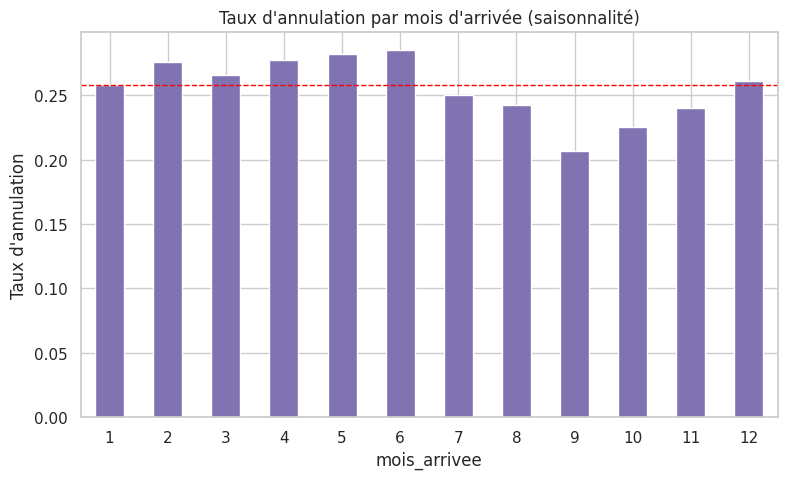

,mean,count
mois_arrivee,,
1,0.258410,654
2,0.275714,700
3,0.265896,865
4,0.277500,800
5,0.282116,794
6,0.285075,670
7,0.250366,683
8,0.242215,578
9,0.206463,557


In [19]:
month_arrivee = train.groupby(train["date_arrivee"].dt.month)["reservation_annulee"].agg(["mean", "count"])
month_arrivee.index.name = "mois_arrivee"

fig, ax = plt.subplots()
month_arrivee["mean"].plot(kind="bar", ax=ax, color="#8172B2")
ax.axhline(train["reservation_annulee"].mean(), color="red", linestyle="--", linewidth=1)
ax.set_title("Taux d'annulation par mois d'arrivée (saisonnalité)")
ax.set_ylabel("Taux d'annulation")
ax.tick_params(axis="x", rotation=0)
plt.show()
month_arrivee

On observe une légère saisonnalité : les arrivées de septembre-octobre annulent un peu moins (~21-23%)
que celles du printemps/début d'été (avril-juin, ~28%). Cela pourra être capté par une variable
`mois_arrivee` en feature engineering (notebook 04).

### 1.10 Synthèse de l'EDA

| Constat | Implication pour la suite |
|---|---|
| Cible déséquilibrée (~26% d'annulations) | F1-score comme métrique, attention au seuil de décision |
| `region_hotel` / `ville` / `type_destination` redondantes | Ne garder que `type_destination` (`src/config.DROP_COLS`) |
| `agent_id` manquant = signal structurel (canal direct) | Pas d'imputation "aveugle" ; remplacé par catégorie `"direct"` |
| `marche_origine`, `enfants`, `prix_moyen_nuit_eur`, `demandes_speciales` : NA sans lien fort à la cible | Imputation simple (médiane / catégorie "Inconnu") sans risque de biais majeur |
| `type_acompte`, `tarif_remboursable`, `canal_reservation` : fort pouvoir discriminant | Variables clés pour la baseline et le modèle final |
| `delai_reservation_jours` : relation non linéaire | Candidate au binning en feature engineering |
| Outliers plausibles, pas d'erreurs de saisie | Pas de suppression ; standardisation pour la régression logistique |
| Pas de dérive nette du taux d'annulation dans le temps, mais split temporel train/test strict | Validation temporelle obligatoire (`src/data.temporal_split`) |
| Légère saisonnalité du mois d'arrivée | Feature engineering possible (`mois_arrivee`) |
